In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\DELL\Downloads\hotel_bookings.csv.zip")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [8]:
df.shape
df.describe
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [9]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [10]:
missing = df.isnull().sum()

missing[missing > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

In [12]:
# handling missing values
df["children"] = df["children"].fillna(0)

In [13]:
df["children"] = df["children"].astype(int)

In [14]:
# remove unnecessary columns
df = df.drop(columns=["agent", "company"])

In [15]:
df.isnull().sum()

hotel                               0
is_canceled                         0
lead_time                           0
arrival_date_year                   0
arrival_date_month                  0
arrival_date_week_number            0
arrival_date_day_of_month           0
stays_in_weekend_nights             0
stays_in_week_nights                0
adults                              0
children                            0
babies                              0
meal                                0
country                           488
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
days_in_waiting_list                0
customer_type                       0
adr                                 0
required_car

In [16]:
# remove duplicated records
df.duplicated().sum()

np.int64(32020)

In [17]:
df = df.drop_duplicates()

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(87370, 30)

In [20]:
df["hotel"].unique()

<StringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str

In [21]:
df["customer_type"].unique()

<StringArray>
['Transient', 'Contract', 'Transient-Party', 'Group']
Length: 4, dtype: str

In [22]:
df["deposit_type"].unique()

<StringArray>
['No Deposit', 'Refundable', 'Non Refund']
Length: 3, dtype: str

In [23]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"] + "-" +
    df["arrival_date_day_of_month"].astype(str)
)

In [ ]:
# create total stay
df["total_stay"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

In [25]:
# create total guest
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

In [26]:
df[df["total_guests"] == 0].shape

(166, 33)

In [27]:
df = df[df["total_guests"] > 0]

In [28]:
df["estimated_revenue"] = (
    df["adr"] * df["total_stay"]
)

In [29]:
df["hotel"].value_counts()

hotel
City Hotel      53260
Resort Hotel    33944
Name: count, dtype: int64

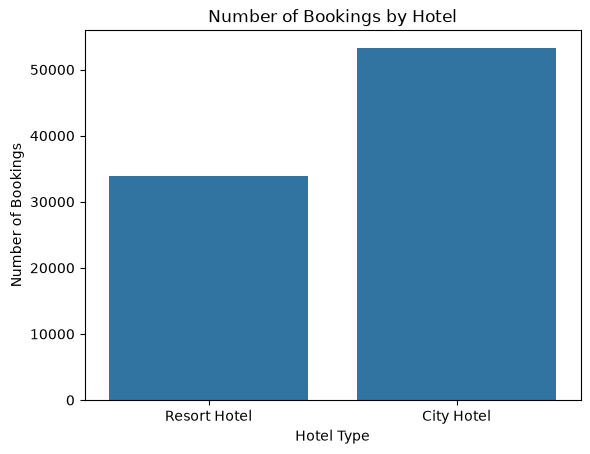

In [30]:
sns.countplot(data=df, x="hotel")

plt.title("Number of Bookings by Hotel")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.show()

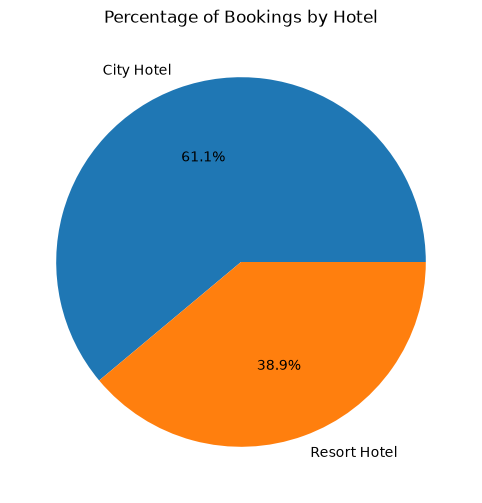

In [31]:
hotel_percentage = df["hotel"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))

plt.pie(
    hotel_percentage,
    labels=hotel_percentage.index,
    autopct="%1.1f%%"
)

plt.title("Percentage of Bookings by Hotel")

plt.show()

In [32]:
df["customer_type"].value_counts()

customer_type
Transient          71843
Transient-Party    11685
Contract            3135
Group                541
Name: count, dtype: int64

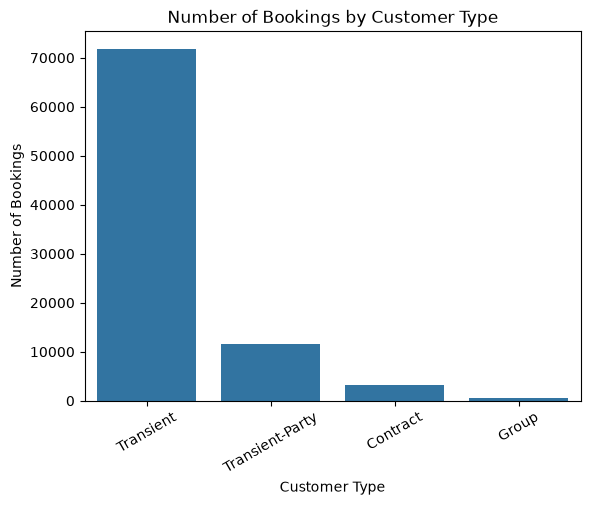

In [33]:
# visualize customer types
sns.countplot(
    data=df,
    x="customer_type",
    order=df["customer_type"].value_counts().index
)

plt.title("Number of Bookings by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=30)

plt.show()

In [34]:
df["country"].value_counts().head(10)

country
PRT    27342
GBR    10422
FRA     8823
ESP     7242
DEU     5383
ITA     3060
IRL     3015
BEL     2081
BRA     1991
NLD     1910
Name: count, dtype: int64

In [35]:
# Q2. What percentage of bookings belong to each hotel?

df["hotel"].value_counts(normalize=True) * 100

hotel
City Hotel      61.07518
Resort Hotel    38.92482
Name: proportion, dtype: float64

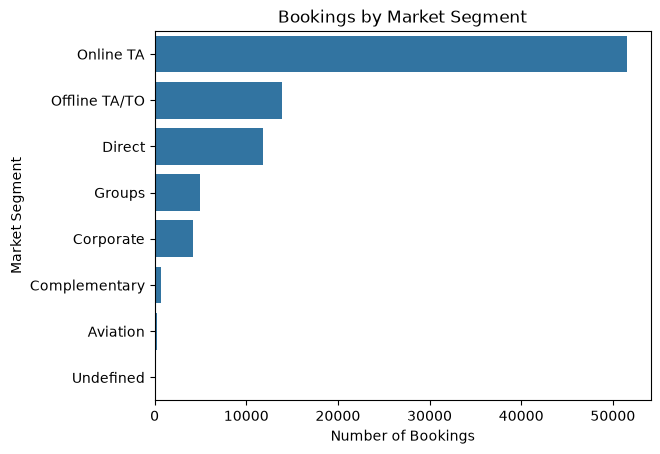

In [37]:
sns.countplot(
    data=df,
    y="market_segment",
    order=df["market_segment"].value_counts().index
)

plt.title("Bookings by Market Segment")
plt.xlabel("Number of Bookings")
plt.ylabel("Market Segment")
plt.show()

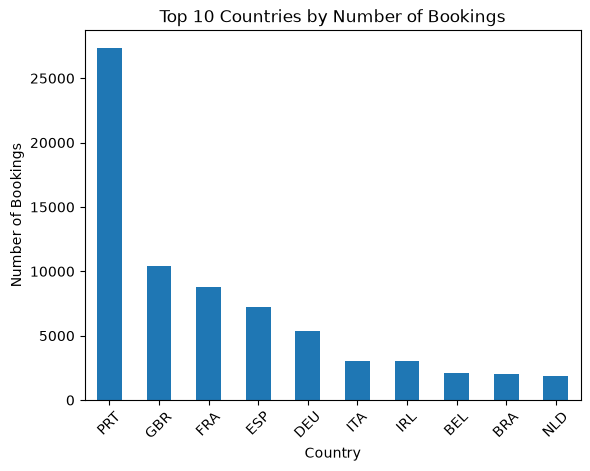

In [38]:
# visualization
top_countries = df["country"].value_counts().head(10)

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Number of Bookings")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

In [39]:
# cancellation analysis
# Q6. What percentage of hotel bookings were cancelled?

df["is_canceled"].value_counts(normalize=True) * 100

is_canceled
0    72.472593
1    27.527407
Name: proportion, dtype: float64

In [40]:
# Q7. Which hotel has the higher cancellation rate?

df.groupby("hotel")["is_canceled"].mean() * 100

hotel
City Hotel      30.103267
Resort Hotel    23.485741
Name: is_canceled, dtype: float64

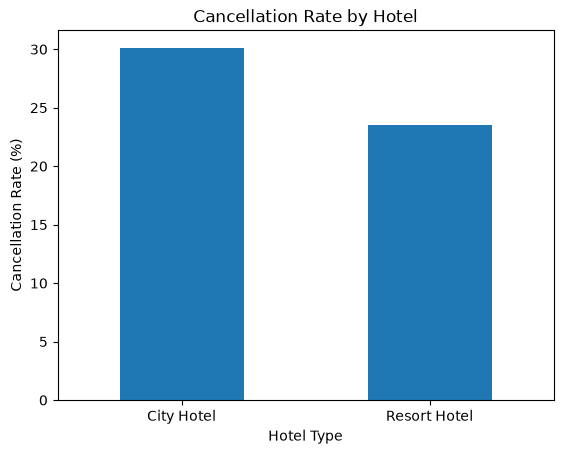

In [41]:
cancellation_rate = df.groupby("hotel")["is_canceled"].mean() * 100

cancellation_rate.plot(kind="bar")

plt.title("Cancellation Rate by Hotel")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [42]:
# lead time analysis
# Create groups based on booking lead time

df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=[-1, 30, 90, 180, np.inf],
    labels=["0-30 days", "31-90 days", "91-180 days", "180+ days"]
)

In [43]:
# Q8. Does booking lead time affect the cancellation rate?

df.groupby(
    "lead_time_group",
    observed=True
)["is_canceled"].mean() * 100

lead_time_group
0-30 days      16.445500
31-90 days     32.047726
91-180 days    35.003567
180+ days      39.741409
Name: is_canceled, dtype: float64

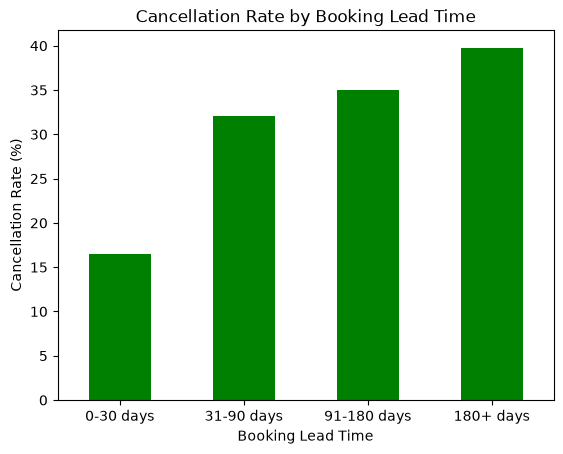

In [45]:
lead_cancel = df.groupby(
    "lead_time_group",
    observed=True
)["is_canceled"].mean() * 100

lead_cancel.plot(kind="bar",color="g")

plt.title("Cancellation Rate by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [46]:
# pricing analysis
# Q9. What is the average daily rate (ADR) of the bookings?

df["adr"].mean()

np.float64(106.52400600889867)

In [47]:
# Q14. How does the number of special requests relate to cancellation?

df.groupby("total_of_special_requests")["is_canceled"].mean() * 100

total_of_special_requests
0    33.258704
1    22.437778
2    21.326210
3    17.113224
4    10.625000
5     5.555556
Name: is_canceled, dtype: float64

In [48]:
# correlation analysis
# Q15. What relationships exist between the main numerical variables?

correlation = df[
    [
        "is_canceled",
        "lead_time",
        "adr",
        "total_stay",
        "total_guests",
        "total_of_special_requests"
    ]
].corr()

correlation

,is_canceled,lead_time,adr,total_stay,total_guests,total_of_special_requests
is_canceled,1.000000,0.184469,0.127229,0.085400,0.098869,-0.120825
lead_time,0.184469,1.000000,0.021889,0.320851,0.125177,0.034009
adr,0.127229,0.021889,1.000000,0.056011,0.382203,0.137400
total_stay,0.085400,0.320851,0.056011,1.000000,0.106993,0.040733
total_guests,0.098869,0.125177,0.382203,0.106993,1.000000,0.127820
total_of_special_requests,-0.120825,0.034009,0.137400,0.040733,0.127820,1.000000


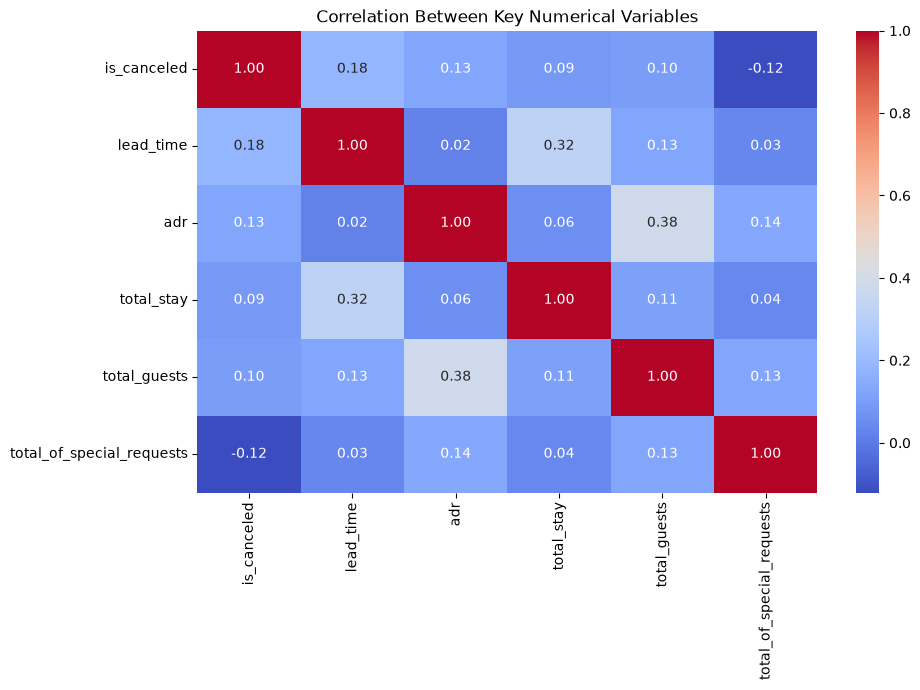

In [49]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Key Numerical Variables")
plt.show()

In [50]:
df.shape

(87204, 35)

In [51]:
# Save the final cleaned dataset for SQL analysis

df.to_csv("../dataset/hotel_bookings_cleaned.csv", index=False)

In [52]:
df.shape

(87204, 35)

In [53]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date',
 'arrival_date',
 'total_stay',
 'total_guests',
 'estimated_revenue',
 'lead_time_group']

In [54]:
print("\n".join(df.columns))

hotel
is_canceled
lead_time
arrival_date_year
arrival_date_month
arrival_date_week_number
arrival_date_day_of_month
stays_in_weekend_nights
stays_in_week_nights
adults
children
babies
meal
country
market_segment
distribution_channel
is_repeated_guest
previous_cancellations
previous_bookings_not_canceled
reserved_room_type
assigned_room_type
booking_changes
deposit_type
days_in_waiting_list
customer_type
adr
required_car_parking_spaces
total_of_special_requests
reservation_status
reservation_status_date
arrival_date
total_stay
total_guests
estimated_revenue
lead_time_group


In [55]:
for i, col in enumerate(df.columns, 1):
    print(i, col)

1 hotel
2 is_canceled
3 lead_time
4 arrival_date_year
5 arrival_date_month
6 arrival_date_week_number
7 arrival_date_day_of_month
8 stays_in_weekend_nights
9 stays_in_week_nights
10 adults
11 children
12 babies
13 meal
14 country
15 market_segment
16 distribution_channel
17 is_repeated_guest
18 previous_cancellations
19 previous_bookings_not_canceled
20 reserved_room_type
21 assigned_room_type
22 booking_changes
23 deposit_type
24 days_in_waiting_list
25 customer_type
26 adr
27 required_car_parking_spaces
28 total_of_special_requests
29 reservation_status
30 reservation_status_date
31 arrival_date
32 total_stay
33 total_guests
34 estimated_revenue
35 lead_time_group


In [56]:
df.columns[25:31].tolist()

['adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date',
 'arrival_date']